# Stage 06B — RAISE-1k manifest and resumable NEF download

## tl;dr

This notebook validates the official RAISE-1k CSV manifest, freezes source roles without using reconstruction outcomes, and downloads **only the 1,000 NEF originals** in resumable shards. It deliberately does not download the parallel TIFF copies.

The supplied manifest contains 1,000 unique sources and direct NEF/TIFF URLs. Its `File Size` column indicates approximately 17 GiB for the NEF set. Use one `SHARD_INDEX` at a time, or duplicate the notebook across Colab sessions with different indices.

This is input preparation only. It does not train a model, inspect Stage 06 outcomes, or alter Stage 05.

## Context & Methods

### Key assumptions

- The CSV ZIP was obtained from the official RAISE-1k access form.
- NEF is the canonical external input. TIFF is omitted to avoid a second, much larger representation of the same sources.
- Source roles are assigned from metadata only, with a fixed seed and camera-stratified sequential splits: 500 development fit, 150 early-stop, 150 calibration, 50 external pilot, and 150 independent test.
- The independent role is an identity assignment only; no reconstruction outcome is generated or inspected here.
- Downloads use `.part` files and HTTP Range requests when supported. A final file is accepted only after its server-reported byte count is satisfied.

Official dataset page: <https://loki.disi.unitn.it/RAISE/>

In [1]:
import os, json, hashlib, time
from pathlib import Path
from zipfile import ZipFile
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from IPython.display import display

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive')
    PROJECT_DIR = Path('/content/drive/MyDrive/reliable-reconstruction-under-mismatch')
else:
    PROJECT_DIR = Path.cwd()

MANIFEST_ZIP_TEXT = ''  # @param {type:"string"}
SHARD_INDEX = 0  # @param {type:"integer"}
SHARD_COUNT = 20  # @param {type:"integer"}
CONCURRENCY = 4  # @param {type:"integer"}
DOWNLOAD = True  # @param {type:"boolean"}
SEED = 20260925

if os.environ.get('STAGE06_SKIP_DOWNLOAD') == '1':
    DOWNLOAD = False
manifest_override = os.environ.get('STAGE06_MANIFEST_ZIP', '').strip()
MANIFEST_ZIP = Path(manifest_override or MANIFEST_ZIP_TEXT or (PROJECT_DIR / 'inputs' / 'RAISE-1k' / 'RAISE_1k.csv.zip'))
INPUT_ROOT = PROJECT_DIR / 'inputs' / 'RAISE-1k'
NEF_DIR = INPUT_ROOT / 'NEF'
RECEIPT_DIR = INPUT_ROOT / 'receipts'
NEF_DIR.mkdir(parents=True, exist_ok=True)
RECEIPT_DIR.mkdir(parents=True, exist_ok=True)

assert MANIFEST_ZIP.is_file(), f'Missing manifest ZIP: {MANIFEST_ZIP}'
assert SHARD_COUNT > 0 and 0 <= SHARD_INDEX < SHARD_COUNT
assert 1 <= CONCURRENCY <= 8
print({'manifest': str(MANIFEST_ZIP), 'shard': f'{SHARD_INDEX:02d}/{SHARD_COUNT:02d}', 'download': DOWNLOAD})

{'manifest': '/workspace/scratch/af6f5594d86c/upload/RAISE_1k.csv.zip', 'shard': '00/20', 'download': False}


## Data

### 1. Validate the official manifest

In [2]:
def sha256_file(path, block_size=1024 * 1024):
    digest = hashlib.sha256()
    with Path(path).open('rb') as stream:
        for block in iter(lambda: stream.read(block_size), b''):
            digest.update(block)
    return digest.hexdigest()

with ZipFile(MANIFEST_ZIP) as archive:
    names = archive.namelist()
    assert names == ['RAISE_1k.csv'], names
    csv_bytes = archive.read(names[0])

manifest = pd.read_csv(pd.io.common.BytesIO(csv_bytes), dtype=str, keep_default_na=False)
required = {'File', 'NEF', 'TIFF', 'File Size', 'Image Size', 'Device', 'Keywords'}
assert required <= set(manifest.columns), sorted(required - set(manifest.columns))
assert len(manifest) == 1000
assert manifest['File'].nunique() == 1000 and not manifest['File'].duplicated().any()
assert manifest['NEF'].nunique() == 1000 and manifest['NEF'].str.startswith('http').all()
assert manifest['TIFF'].nunique() == 1000 and manifest['TIFF'].str.startswith('http').all()
assert (manifest['NEF'].str.strip() != '').all() and (manifest['TIFF'].str.strip() != '').all()
manifest['expected_mb'] = manifest['File Size'].str.extract(r'([0-9.]+)')[0].astype(float)
manifest['source_id'] = manifest['File'].astype(str)
manifest['relative_path'] = manifest['source_id'] + '.NEF'

manifest_receipt = {
    'zip_sha256': sha256_file(MANIFEST_ZIP),
    'csv_sha256': hashlib.sha256(csv_bytes).hexdigest(),
    'source_count': int(len(manifest)),
    'estimated_nef_gib': float(manifest['expected_mb'].sum() / 1024),
    'devices': {str(k): int(v) for k, v in manifest['Device'].value_counts().items()},
}
print(json.dumps(manifest_receipt, indent=2))
display(manifest[['source_id', 'Device', 'Image Size', 'File Size', 'Keywords']].head())

{
  "zip_sha256": "2bf21449ed458502c09407cd9260b5d91fe27e7bc9e98f33bd108bbd8e40f8dc",
  "csv_sha256": "b388d84a73b17f3c1790a55e28777c6b9bed2806b2a86b9fc05ed28b863cc8c7",
  "source_count": 1000,
  "estimated_nef_gib": 16.996923828125,
  "devices": {
    "Nikon D7000": 729,
    "Nikon D90": 263,
    "Nikon D40": 8
  }
}
    source_id       Device       Image Size File Size            Keywords
0  r000da54ft    Nikon D90  L (4288 x 2848)   9.79 MB     nature; outdoor
1  r001d260dt  Nikon D7000  L (4928 x 3264)   20.0 MB  buildings; outdoor
2  r002fc3e2t  Nikon D7000  L (4928 x 3264)   21.5 MB     outdoor; people
3  r00444b95t  Nikon D7000  L (4928 x 3264)   19.8 MB  buildings; outdoor
4  r005f3e70t    Nikon D90  L (4288 x 2848)   10.6 MB  buildings; outdoor


### 2. Freeze source roles from metadata only

In [3]:
def split_stratified(indices, test_size, seed):
    selected_train, selected_test = train_test_split(
        indices,
        test_size=test_size,
        random_state=seed,
        shuffle=True,
        stratify=manifest.loc[indices, 'Device'],
    )
    return list(selected_train), list(selected_test)

roles = pd.Series(index=manifest.index, dtype='object')

# Nikon D40 contributes only eight sources. Allocate it explicitly so every
# role contains at least one D40 source; stratify the remaining two cameras.
def role_key(index):
    source_id = manifest.loc[index, 'source_id']
    return hashlib.sha256(f'{SEED}:role:{source_id}'.encode()).hexdigest()

d40 = sorted(manifest.index[manifest['Device'] == 'Nikon D40'].tolist(), key=role_key)
assert len(d40) == 8
d40_roles = (
    ['development_fit'] * 4
    + ['development_early_stop', 'development_calibration', 'external_pilot', 'independent_test']
)
for index, role in zip(d40, d40_roles):
    roles.loc[index] = role

remaining = manifest.index[manifest['Device'] != 'Nikon D40'].tolist()
remaining, chosen = split_stratified(remaining, 149, SEED + 1)
roles.loc[chosen] = 'independent_test'
remaining, chosen = split_stratified(remaining, 49, SEED + 2)
roles.loc[chosen] = 'external_pilot'
remaining, chosen = split_stratified(remaining, 149, SEED + 3)
roles.loc[chosen] = 'development_calibration'
remaining, chosen = split_stratified(remaining, 149, SEED + 4)
roles.loc[chosen] = 'development_early_stop'
roles.loc[remaining] = 'development_fit'
manifest['role'] = roles

expected_counts = {
    'development_fit': 500,
    'development_early_stop': 150,
    'development_calibration': 150,
    'external_pilot': 50,
    'independent_test': 150,
}
assert manifest['role'].value_counts().to_dict() == expected_counts
assert manifest.groupby('source_id')['role'].nunique().max() == 1

balance = pd.crosstab(manifest['role'], manifest['Device'])
display(balance)
keyword_balance = (
    manifest.assign(keyword=manifest['Keywords'].str.split(';'))
    .explode('keyword')
    .assign(keyword=lambda x: x['keyword'].str.strip().str.lower())
    .groupby(['role', 'keyword']).size().unstack(fill_value=0)
)
display(keyword_balance)

Device                   Nikon D40  Nikon D7000  Nikon D90
role                                                      
development_calibration          1          110         39
development_early_stop           1          109         40
development_fit                  4          365        131
external_pilot                   1           36         13
independent_test                 1          109         40
keyword                  buildings  indoor  landscape  ...  objects  outdoor  people
role                                                   ...                          
development_calibration         53      29         47  ...       22      121      21
development_early_stop          38      23         44  ...       18      127      20
development_fit                149      77        150  ...       59      423      70
external_pilot                  18       7         18  ...        6       43       6
independent_test                34      22         41  ...       23      128 

## Results

### 3. Inspect role balance and assign download shards

Wrote: /workspace/scratch/af6f5594d86c/inputs/RAISE-1k/source_roles.csv
role            development_calibration  ...  independent_test
download_shard                           ...                  
0                                     6  ...                 7
1                                     8  ...                 9
2                                     9  ...                 5
3                                     5  ...                 8
4                                     8  ...                 8

[5 rows x 5 columns]
Selected shard sources: 50


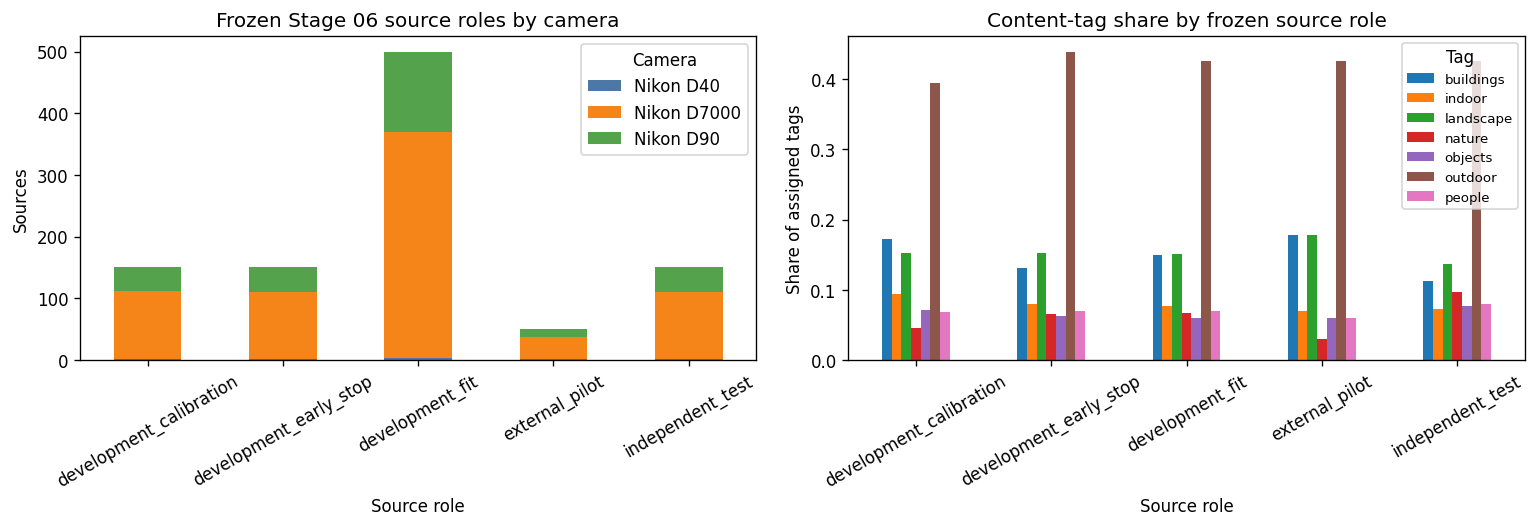

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
balance.plot(kind='bar', stacked=True, ax=axes[0], color=['#4C78A8', '#F58518', '#54A24B'])
axes[0].set_title('Frozen Stage 06 source roles by camera')
axes[0].set_xlabel('Source role')
axes[0].set_ylabel('Sources')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(title='Camera')

keyword_share = keyword_balance.div(keyword_balance.sum(axis=1), axis=0)
keyword_share.plot(kind='bar', ax=axes[1])
axes[1].set_title('Content-tag share by frozen source role')
axes[1].set_xlabel('Source role')
axes[1].set_ylabel('Share of assigned tags')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Tag', fontsize=8)
plt.tight_layout()
plt.show()

def stable_key(source_id):
    return hashlib.sha256(f'{SEED}:{source_id}'.encode()).hexdigest()

manifest = manifest.sort_values('source_id').reset_index(drop=True)
download_order = sorted(range(len(manifest)), key=lambda i: stable_key(manifest.loc[i, 'source_id']))
download_shards = np.empty(len(manifest), dtype=int)
for order, row_index in enumerate(download_order):
    download_shards[row_index] = order % SHARD_COUNT
manifest['download_shard'] = download_shards

role_manifest = manifest[['source_id', 'relative_path', 'role', 'Device', 'Image Size', 'Keywords', 'NEF', 'expected_mb', 'download_shard']].copy()
role_manifest.columns = ['source_id', 'relative_path', 'role', 'device', 'image_size', 'keywords', 'nef_url', 'expected_mb', 'download_shard']
role_manifest_path = INPUT_ROOT / 'source_roles.csv'
role_manifest.to_csv(role_manifest_path, index=False)
print('Wrote:', role_manifest_path)
display(pd.crosstab(role_manifest['download_shard'], role_manifest['role']).head())
print('Selected shard sources:', int((role_manifest['download_shard'] == SHARD_INDEX).sum()))

### 4. Download the selected NEF shard with resume support

In [5]:
session = requests.Session()
session.headers.update({'User-Agent': 'Stage06-RAISE-research-downloader/1.0'})

def remote_size(url):
    response = session.head(url, allow_redirects=True, timeout=60)
    response.raise_for_status()
    value = response.headers.get('Content-Length')
    if value is None:
        raise RuntimeError(f'No Content-Length for {url}')
    return int(value)

def download_one(record):
    source_id = record['source_id']
    url = record['nef_url']
    destination = NEF_DIR / record['relative_path']
    partial = destination.with_suffix(destination.suffix + '.part')
    expected = remote_size(url)
    if destination.is_file() and destination.stat().st_size == expected:
        return {'source_id': source_id, 'path': destination.name, 'byte_count': expected, 'sha256': sha256_file(destination), 'status': 'verified_existing'}
    if destination.exists():
        destination.replace(partial)
    offset = partial.stat().st_size if partial.exists() else 0
    if offset > expected:
        partial.unlink()
        offset = 0
    headers = {'Range': f'bytes={offset}-'} if offset else {}
    with session.get(url, headers=headers, stream=True, timeout=(30, 180)) as response:
        if offset and response.status_code != 206:
            partial.unlink(missing_ok=True)
            offset = 0
            response.close()
            return download_one(record)
        response.raise_for_status()
        mode = 'ab' if offset else 'wb'
        with partial.open(mode) as stream:
            for block in response.iter_content(chunk_size=1024 * 1024):
                if block:
                    stream.write(block)
    assert partial.stat().st_size == expected, (source_id, partial.stat().st_size, expected)
    partial.replace(destination)
    return {'source_id': source_id, 'path': destination.name, 'byte_count': expected, 'sha256': sha256_file(destination), 'status': 'downloaded'}

selected = role_manifest.loc[role_manifest['download_shard'] == SHARD_INDEX].to_dict('records')
download_records = []
if DOWNLOAD:
    started = time.time()
    with ThreadPoolExecutor(max_workers=CONCURRENCY) as pool:
        futures = {pool.submit(download_one, record): record['source_id'] for record in selected}
        for position, future in enumerate(as_completed(futures), start=1):
            result = future.result()
            download_records.append(result)
            print(f'[{position:03d}/{len(selected):03d}] {result["source_id"]}: {result["status"]}')
    print(f'Elapsed minutes: {(time.time() - started) / 60:.1f}')
else:
    print('DOWNLOAD=False: validation-only execution; no NEF files were downloaded.')

DOWNLOAD=False: validation-only execution; no NEF files were downloaded.


### 5. Seal the shard receipt

In [6]:
receipt_csv = RECEIPT_DIR / f'download_shard_{SHARD_INDEX:02d}_of_{SHARD_COUNT:02d}.csv'
receipt_json = RECEIPT_DIR / f'download_shard_{SHARD_INDEX:02d}_of_{SHARD_COUNT:02d}.json'
if DOWNLOAD:
    receipt_frame = pd.DataFrame(download_records).sort_values('source_id')
    assert len(receipt_frame) == len(selected)
    assert receipt_frame['source_id'].nunique() == len(selected)
    receipt_frame.to_csv(receipt_csv, index=False)
    receipt = {
        'stage': '06B_RAISE_1k_download',
        'manifest_zip_sha256': manifest_receipt['zip_sha256'],
        'source_roles_sha256': sha256_file(role_manifest_path),
        'shard_index': SHARD_INDEX,
        'shard_count': SHARD_COUNT,
        'source_count': len(selected),
        'byte_count': int(receipt_frame['byte_count'].sum()),
        'receipt_csv': receipt_csv.name,
        'receipt_csv_sha256': sha256_file(receipt_csv),
    }
    receipt_json.write_text(json.dumps(receipt, indent=2) + '\n')
    print(json.dumps(receipt, indent=2))
else:
    print({'validation_only': True, 'planned_sources': len(selected), 'planned_gib_approx': sum(float(r['expected_mb']) for r in selected) / 1024})

{'validation_only': True, 'planned_sources': 50, 'planned_gib_approx': 0.814765625}


## Takeaways

- Use **NEF only** for the external source archive; the TIFF URLs are alternate representations of the same 1,000 sources.
- Each shard contains 50 sources when `SHARD_COUNT=20`, approximately 0.85 GiB on average.
- A shard is complete only when its CSV/JSON receipt has been written.
- Run every shard index from `0` through `19`. Different Colab sessions may run different indices concurrently because filenames are source-unique.
- Do not run reconstruction or open any independent-test outcome until the overlap audit, solver settings, thresholds, models, sample-size calculation, and freeze bundle have passed.